# The "aprox13" network

The aprox13 network is widely used for explosive He burning in multidimensional simulations.  It has 2 main approximations:

* C+C, C+O, and O+O burning are simplified, removing the intermediate nucleus from the proton emission branch and neglecting the neutron-emission branch
* The $(\alpha,p)(p,\gamma)$ links are combined with $(\alpha,\gamma)$

We can do both approximations.

## A starting network

To begin, we'll create a network will all of the nuclei (including those that will be approximated out later).  We'll use {py:func}`network_helper <pynucastro.networks.helper.network_helper>` so we automatically rederive reverse rates using detailed balance.

In [1]:
import pynucastro as pyna

In [66]:
import matplotlib.pyplot as plt
SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 22
MAJOR_TICK_SIZE = 5
MINOR_TICK_SIZE = 3

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('xtick.major', size=MAJOR_TICK_SIZE, width=1.5)
plt.rc('xtick.minor', size=MINOR_TICK_SIZE, width=1)
plt.rc('ytick.major', size=MAJOR_TICK_SIZE, width=1.5)
plt.rc('ytick.minor', size=MINOR_TICK_SIZE, width=1)
plt.rcParams.update({'lines.linewidth': 2.5})

In [3]:
net = pyna.network_helper(["p", "he4",
                           "c12", "o16", "ne20", "na23",
                           "mg24", "al27", "si28", "p31", "s32",
                           "cl35", "ar36", "k39", "ca40",
                           "sc43", "ti44", "v47", "cr48",
                           "mn51", "fe52", "co55", "ni56"])

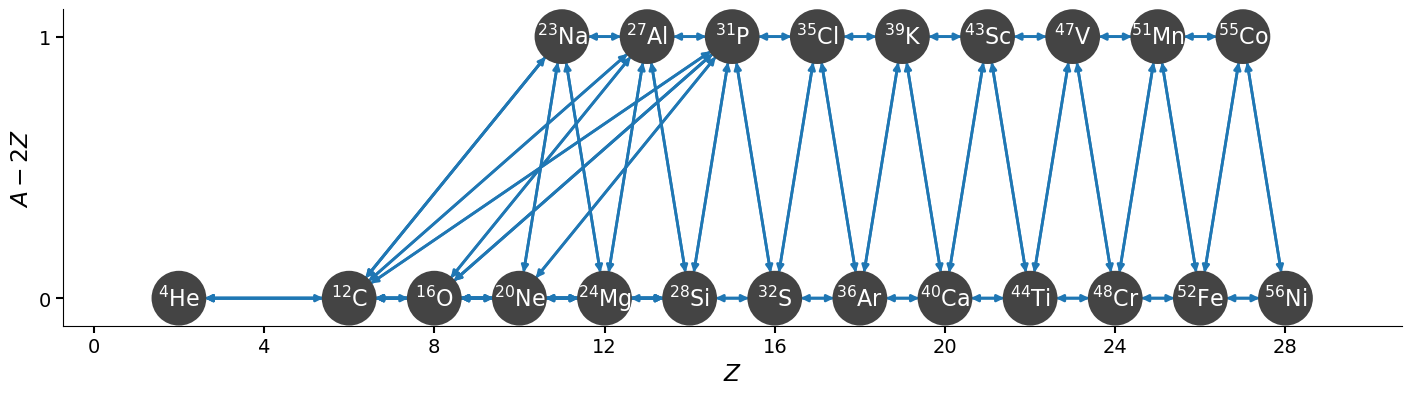

In [4]:
fig = net.plot(rotated=True, hide_xalpha=True,
               size=(1400, 400), node_size=1400, node_font_size=16)

In [5]:
fig.savefig("aprox13-full.pdf")

In [6]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 23
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? True

  total number of rates: 92

  rates explicitly connecting nuclei: 92
  hidden rates: 0

  reaclib rates: 46
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 0
  derived rates: 46
  modified rates: 0
  custom rates: 0


In [7]:
for rp in sorted(net.get_rate_pairs(), key=lambda x: max(x.forward.reactants)):
    print(f"{rp.forward!s:25}, {rp.reverse!s:25}")

3 He4 ⟶ C12 + 𝛾          , C12 ⟶ 3 He4              
C12 + He4 ⟶ O16 + 𝛾      , O16 ⟶ He4 + C12          
C12 + C12 ⟶ p + Na23     , Na23 + p ⟶ C12 + C12     
C12 + C12 ⟶ He4 + Ne20   , Ne20 + He4 ⟶ C12 + C12   
O16 + He4 ⟶ Ne20 + 𝛾     , Ne20 ⟶ He4 + O16         
O16 + C12 ⟶ p + Al27     , Al27 + p ⟶ C12 + O16     
O16 + C12 ⟶ He4 + Mg24   , Mg24 + He4 ⟶ C12 + O16   
O16 + O16 ⟶ p + P31      , P31 + p ⟶ O16 + O16      
O16 + O16 ⟶ He4 + Si28   , Si28 + He4 ⟶ O16 + O16   
Ne20 + He4 ⟶ Mg24 + 𝛾    , Mg24 ⟶ He4 + Ne20        
Ne20 + C12 ⟶ p + P31     , P31 + p ⟶ C12 + Ne20     
Ne20 + C12 ⟶ He4 + Si28  , Si28 + He4 ⟶ C12 + Ne20  
Na23 + p ⟶ Mg24 + 𝛾      , Mg24 ⟶ p + Na23          
Na23 + He4 ⟶ Al27 + 𝛾    , Al27 ⟶ He4 + Na23        
Na23 + p ⟶ He4 + Ne20    , Ne20 + He4 ⟶ p + Na23    
Mg24 + He4 ⟶ Si28 + 𝛾    , Si28 ⟶ He4 + Mg24        
Al27 + p ⟶ Si28 + 𝛾      , Si28 ⟶ p + Al27          
Al27 + He4 ⟶ P31 + 𝛾     , P31 ⟶ He4 + Al27         
Al27 + p ⟶ He4 + Mg24    , Mg24 + He4 ⟶ p + Al

## Approximating

Now we'll approximate the C/O burning

In [8]:
from pynucastro.rates.aprox_family_rates import make_CO_approx_rates

In [9]:
approx_net = pyna.PythonNetwork(rates=net.get_rates())

In [10]:
approx_net.make_CO_burning_approx("C")
approx_net.remove_nuclei(["na23"])

In [11]:
approx_net.make_CO_burning_approx("CO")
approx_net.remove_nuclei(["al27"])

In [12]:
approx_net.make_CO_burning_approx("O")
approx_net.remove_nuclei(["p31"])

In [13]:
rne = approx_net.get_rate_by_name("Ne20(C12,a)Si28")
rne_r = approx_net.get_rate_by_name("Si28(a,C12)Ne20")
approx_net.remove_rates([rne, rne_r])

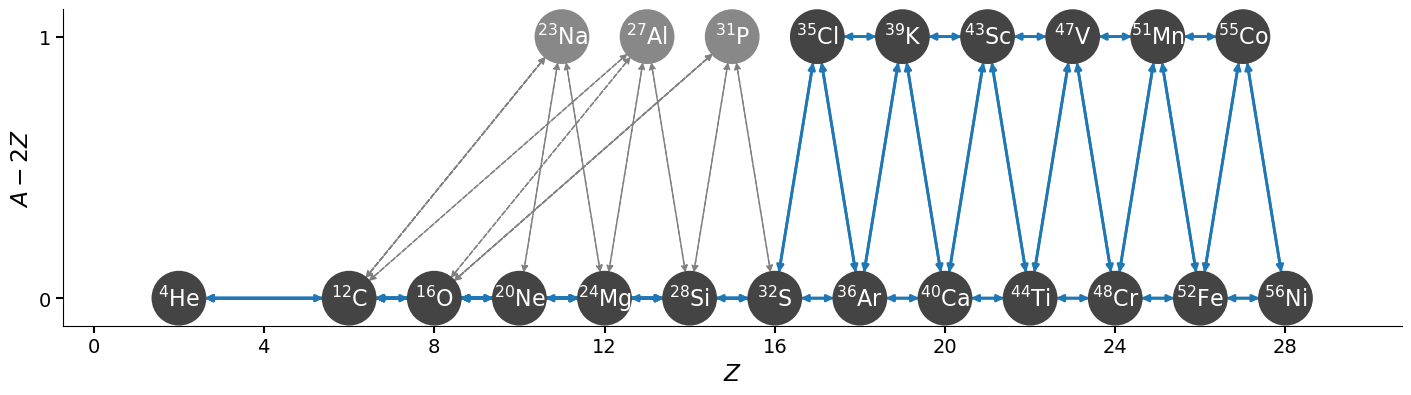

In [14]:
fig = approx_net.plot(rotated=True, hide_xalpha=True,
                      size=(1400, 400), node_size=1400, node_font_size=16)

now the $(\alpha,p)(p,\gamma)$ approximation

In [15]:
approx_net.make_ap_pg_approx(intermediate_nuclei=["cl35", "k39", "sc43", "v47", "mn51", "co55"])
approx_net.remove_nuclei(["cl35", "k39", "sc43", "v47", "mn51", "co55"])

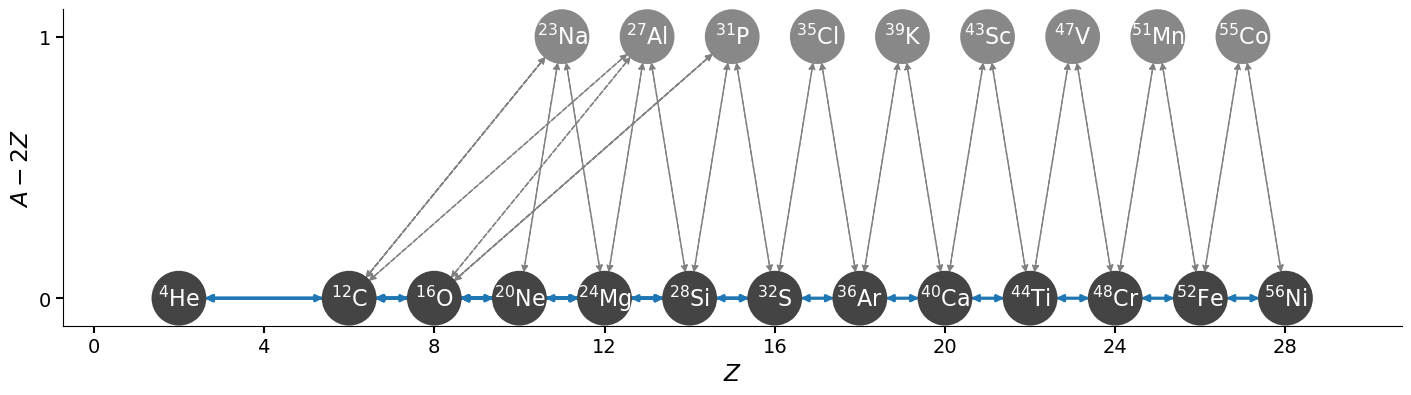

In [16]:
fig = approx_net.plot(rotated=True, hide_xalpha=True,
                      size=(1400, 400), node_size=1400, node_font_size=16)

In [17]:
fig.savefig("aprox13-net.pdf")

In [18]:
approx_net.summary()

Network summary
---------------
  explicitly carried nuclei: 13
  approximated-out nuclei: 9
  inert nuclei (included in carried): 0

  NSE compatible? True

  total number of rates: 102

  rates explicitly connecting nuclei: 36
  hidden rates: 66

  reaclib rates: 36
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 30
  derived rates: 36
  modified rates: 0
  custom rates: 0


In [19]:
for rp in sorted(approx_net.get_rate_pairs(), key=lambda x: max(x.forward.reactants)):
    print(f"{rp.forward!s:25}, {rp.reverse!s:25}")

3 He4 ⟶ C12 + 𝛾          , C12 ⟶ 3 He4              
C12 + He4 ⟶ O16 + 𝛾      , O16 ⟶ He4 + C12          
C12 + C12 ⟶ Mg24 + 𝛾     , Mg24 ⟶ C12 + C12         
C12 + C12 ⟶ Ne20 + He4   , Ne20 + He4 ⟶ C12 + C12   
O16 + He4 ⟶ Ne20 + 𝛾     , Ne20 ⟶ He4 + O16         
C12 + O16 ⟶ Si28 + 𝛾     , Si28 ⟶ O16 + C12         
C12 + O16 ⟶ Mg24 + He4   , Mg24 + He4 ⟶ O16 + C12   
O16 + O16 ⟶ S32 + 𝛾      , S32 ⟶ O16 + O16          
O16 + O16 ⟶ Si28 + He4   , Si28 + He4 ⟶ O16 + O16   
Ne20 + He4 ⟶ Mg24 + 𝛾    , Mg24 ⟶ Ne20 + He4        
Mg24 + He4 ⟶ Si28 + 𝛾    , Si28 ⟶ Mg24 + He4        
Si28 + He4 ⟶ S32 + 𝛾     , S32 ⟶ Si28 + He4         
S32 + He4 ⟶ Ar36 + 𝛾     , Ar36 ⟶ S32 + He4         
Ar36 + He4 ⟶ Ca40 + 𝛾    , Ca40 ⟶ Ar36 + He4        
Ca40 + He4 ⟶ Ti44 + 𝛾    , Ti44 ⟶ Ca40 + He4        
Ti44 + He4 ⟶ Cr48 + 𝛾    , Cr48 ⟶ Ti44 + He4        
Cr48 + He4 ⟶ Fe52 + 𝛾    , Fe52 ⟶ Cr48 + He4        
Fe52 + He4 ⟶ Ni56 + 𝛾    , Ni56 ⟶ Fe52 + He4        


## Comparing the integration

### the full network

In [20]:
import numpy as np
from scipy.integrate import solve_ivp

In [21]:
net.write_network("full_aprox13.py")
import full_aprox13 as fn

/home/zhi/Github/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


In [22]:
rho = 1.e7
T = 3.e9

X0 = np.zeros(fn.nnuc)
X0[fn.jhe4] = 1.0

Y0 = X0 / fn.A

In [23]:
tmax = 1000.0

sol_full = solve_ivp(fn.rhs, [0, tmax], Y0, method="BDF", jac=fn.jacobian,
                     dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-8)

/home/zhi/Github/pynucastro/pynucastro/networks/python_network.py:472: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


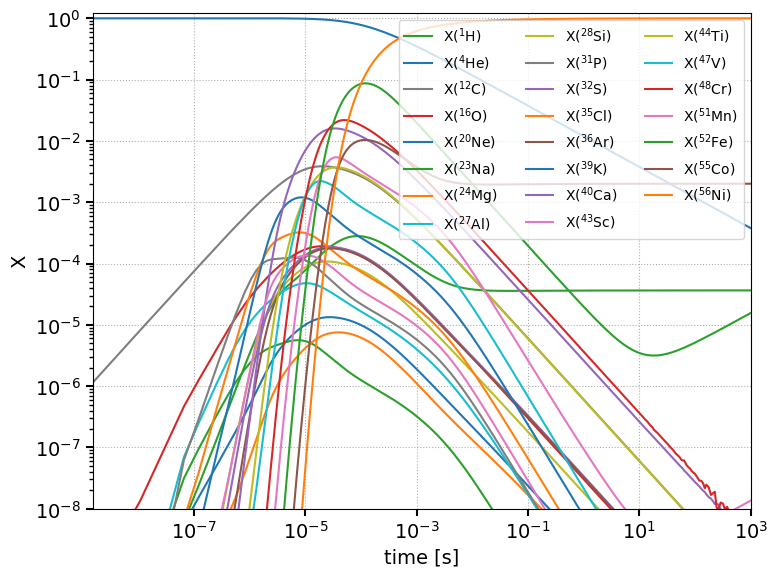

In [24]:
net_sol = pyna.networks.NetworkSolution(sol_full, fn.rhs, fn.jacobian, net, rho, T)
fig = net_sol.plot_evolution(ymin=1.e-6)

### aprox13 net

In [25]:
approx_net.write_network("aprox13.py")
import aprox13 as ap

/home/zhi/Github/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


In [26]:
X0 = np.zeros(ap.nnuc)
X0[ap.jhe4] = 1.0

Y0 = X0 / ap.A

In [27]:
sol_approx = solve_ivp(ap.rhs, [0, tmax], Y0, method="BDF", jac=ap.jacobian,
                       dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-8)

/home/zhi/Github/pynucastro/pynucastro/networks/python_network.py:472: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


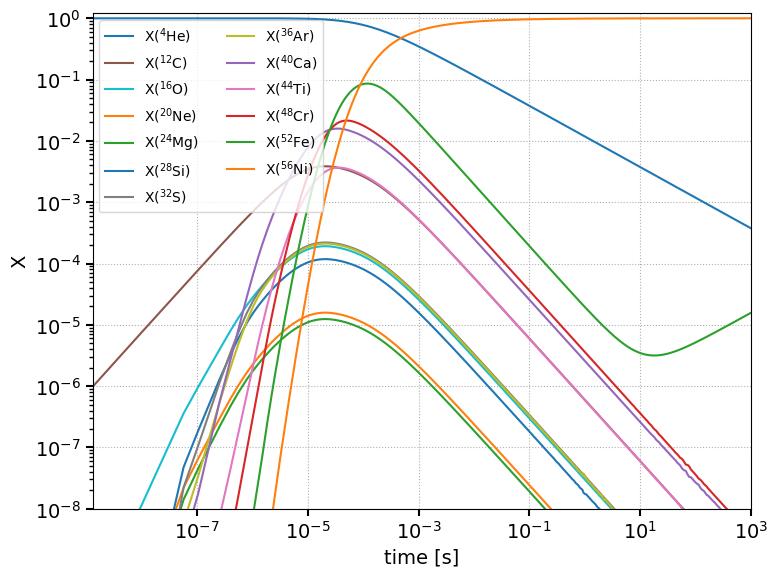

In [28]:
approx_net_sol = pyna.networks.NetworkSolution(sol_approx, ap.rhs, ap.jacobian, approx_net, rho, T)
fig = approx_net_sol.plot_evolution(ymin=1.e-6)

### Comparing

In [29]:
main_nuclei = {"He4": "C0",
               "Ni56": "C1",
               "Fe52": "C2",
               "Cr48": "C3",
               "Ca40": "C4",
               "Ti44": "C5"}
n_nuc = len(net_sol.unique_nuclei)
cmap = plt.get_cmap("turbo")
colors = cmap(np.linspace(0, 1, n_nuc))
nuc_colors = {nuc: colors[i % len(colors)] for i, nuc in enumerate(net_sol.unique_nuclei)}

/tmp/ipykernel_2003536/1966321607.py:55: RuntimeWarning: invalid value encountered in divide
  rel_err = np.abs(X_approx - X_ref) / X_ref
/tmp/ipykernel_2003536/1966321607.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


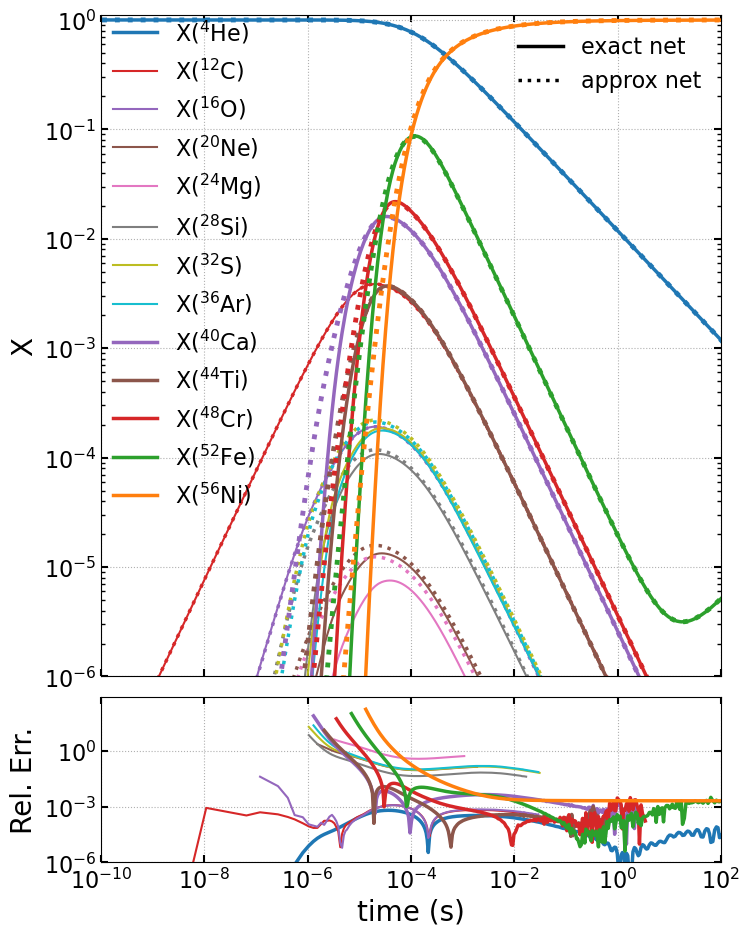

In [69]:
fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(8, 11), sharex=True,
                                 gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05})

# Top Panel
c = 3
for i in range(ap.nnuc):
    if (nm := ap.names[i].capitalize()) in main_nuclei:
        color = main_nuclei[nm]
        lw = 2.5
    else:
        color = f"C{c}"
        lw = 1.5
        c += 1
    ax.loglog(sol_approx.t, sol_approx.y[i,:] * ap.A[i],
              linestyle=":", color=color, lw=lw+1)    
    idx = fn.names.index(ap.names[i])
    ax.loglog(sol_full.t, sol_full.y[idx,:] * fn.A[idx],
              label=rf"X$({pyna.Nucleus(fn.names[idx]).pretty})$",              
              linestyle="-", color=color, lw=lw)

ax.set_ylim(1.e-6, 1.1)
ax.set_xlim(1.e-10, 1.e2)
ax.set_ylabel("X")
ax.grid(ls=":")

# Add species legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", 
           bbox_to_anchor=(0.115, 0.655), ncol=1, frameon=False)

# Add line legend
style_legend = [
    plt.Line2D([0], [0], color="k", linestyle="-", label="exact net"),
    plt.Line2D([0], [0], color="k", linestyle=":", label="approx net"),
]
ax.legend(handles=style_legend, loc="upper right", frameon=False)

# Bot panel for plotting error between common species
X_FLOOR = 1.e-6
c = 3
for i, nuc in enumerate(approx_net_sol.unique_nuclei):
    if (nm := ap.names[i].capitalize()) in main_nuclei:
        color = main_nuclei[nm]
        lw = 2.5
    else:
        color = f"C{c}"
        lw = 1.5
        c += 1
    idx = net_sol.unique_nuclei.index(nuc)
    X_ref = net_sol.X[idx, :]
    X_approx = approx_net_sol.X_at(net_sol.t)[i, :]

    # Only compute error for X greater than absolute tolerance of the integrator
    invalid = X_ref < X_FLOOR
    rel_err = np.abs(X_approx - X_ref) / X_ref
    rel_err[invalid] = np.nan
    
    ax_err.loglog(net_sol.t, rel_err,
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=color, linewidth=lw)

ax_err.set_xlabel("time (s)")
ax_err.set_ylabel("Rel. Err.")
ax_err.grid(ls=":")
ax_err.set_ylim(ymin=1e-6)
for a in (ax, ax_err):
    a.minorticks_on()
    a.tick_params(top=True, bottom=True,
                  left=True, right=True,
                  direction="in", which="both")

We see good agreement for the nuclei the two networks have in common.

In [71]:
fig.tight_layout()
fig.savefig("aprox13-integration-comparison.pdf", bbox_inches="tight", format="pdf")

/tmp/ipykernel_2003536/1209432015.py:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
